In [16]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter
from scipy.optimize import curve_fit

from src.plot_style import set_plot_style

set_plot_style()

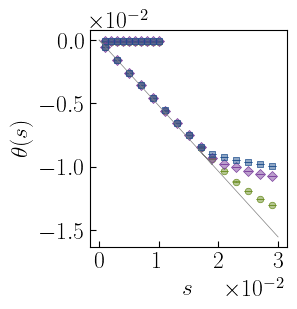

In [18]:
with open('data/SCGF_positive_data.json', 'r') as f:
    data = json.load(f)

def cm_to_inch(cm):
    return cm / 2.54

panel_w, panel_h, margin = 5.0, 5.5, 2.0

fig = plt.figure(figsize=(
    cm_to_inch(panel_w + 2*margin),
    cm_to_inch(panel_h + 2*margin)
))

ax = fig.add_axes([
    margin / (panel_w + 2*margin),
    margin / (panel_h + 2*margin),
    panel_w / (panel_w + 2*margin),
    panel_h / (panel_h + 2*margin)
])

colors = ["#6B8E23", "#7A3E9D", "#1F4E8C"]
colors1 = [mcolors.to_rgba(c, 1.0) for c in colors]
colors03 = [mcolors.to_rgba(c, 0.5) for c in colors]
markers = ['o', 'D', 's']

num_sites_range = [20, 40, 60]
V_values = [5.875, 2.000]

for V in V_values:

    for n, L in enumerate(num_sites_range):

        s_range = np.array(data[f"s_range_V_{V}_L_{L}"])
        large = np.array(data[f"SCGF_positive_V_{V}_L_{L}_large"])
        small = np.array(data[f"SCGF_positive_V_{V}_L_{L}_small"])
        errors = np.abs(large - small)

        ax.errorbar(
            s_range, large, yerr=errors,
            linestyle='None', capsize=3,
            elinewidth=1, capthick=0.5,
            c=colors1[n], zorder=1
        )

        ax.plot(
            s_range, large,
            marker=markers[n], markersize=4.7,
            lw=0.0,
            c=colors03[n],
            markeredgewidth=0.5,
            markeredgecolor=colors1[n]
        )

    s_range = np.array(data[f"s_range_V_{V}"])
    bound = np.array(data[f"bound_V_{V}"])
    ax.plot(s_range, bound, c='grey', lw=0.5)

ax.set_xlabel(r"$s$", fontsize=17)
ax.set_ylabel(r"$\theta(s)$", fontsize=17)

ax.set_xticks([0.0, 0.01, 0.02, 0.03])
ax.set_yticks([0.0, -0.005, -0.010, -0.015])

ax.tick_params(axis='both', labelsize=17)

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(sf)
ax.yaxis.offsetText.set_fontsize(17)

ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax.xaxis.offsetText.set_fontsize(17)

plt.savefig('figures/svg/fig3_d.svg',bbox_inches='tight',dpi=300,transparent=True)
plt.savefig('figures/pdf/fig3_d.pdf',bbox_inches='tight',dpi=300,transparent=True)

plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_14720\2523672350.py:18: RuntimeWarning: invalid value encountered in divide
  activity = np.array(data[f"bound_V_{V}"]) / s_range


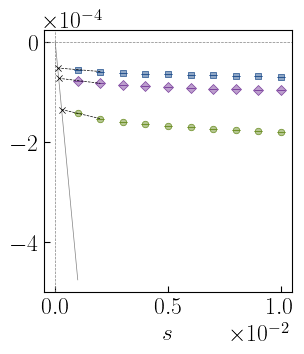

In [19]:
with open('data/SCGF_positive_data.json', 'r') as f:
    data = json.load(f)

def cm_to_inch(cm): return cm / 2.54

fig = plt.figure(figsize=(cm_to_inch(9), cm_to_inch(9.5)))
ax = fig.add_axes([0.22, 0.2, 0.7, 0.7])

colors = ["#6B8E23", "#7A3E9D", "#1F4E8C"]
colors1 = [mcolors.to_rgba(c, 1.0) for c in colors]
colors03 = [mcolors.to_rgba(c, 0.5) for c in colors]
markers = ['o','D','s']

num_sites_range = [20, 40, 60]
V = 5.875

s_range = np.array(data[f"s_range_V_{V}"])
activity = np.array(data[f"bound_V_{V}"]) / s_range

activity = activity[1]

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')

for n, L in enumerate(num_sites_range):

    s_range = np.array(data[f"s_range_zoom_V_{V}"])
    large = np.array(data[f"SCGF_positive_V_{V}_L_{L}_large"])
    small = np.array(data[f"SCGF_positive_V_{V}_L_{L}_small"])
    errors = np.abs(large - small)

    ax.errorbar(
        s_range, large, yerr=errors,
        linestyle='None', capsize=3,
        elinewidth=1, capthick=0.5,
        c=colors1[n], zorder=1
    )

    ax.plot(
        s_range, large,
        marker=markers[n], markersize=4.7,
        lw=0.0,
        c=colors03[n],
        markeredgewidth=0.5,
        markeredgecolor=colors1[n]
    )

    i0, i1 = 0, 1
    m, b = np.polyfit(s_range[i0:i1+1], large[i0:i1+1], 1)

    s_cross = -b / (m - activity)

    ax.scatter(
        s_cross, m*s_cross + b,
        c='black', s=20, marker='x', lw=0.5, zorder=10
    )

    x = np.linspace(s_cross, s_range[i1], 100)
    ax.plot(x, m*x + b, '--', c='black', lw=0.5)

s_small = np.linspace(0, 0.001, 2)
ax.plot(s_small, activity * s_small, c='grey', lw=0.5)

ax.set_xlabel(r"$s$", fontsize=17)
ax.set_xticks([0.0, 0.005, 0.01])

ax.tick_params(axis='both', labelsize=17)

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0,0))
ax.yaxis.set_major_formatter(sf)
ax.yaxis.offsetText.set_fontsize(17)

ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax.xaxis.offsetText.set_fontsize(17)

plt.savefig('figures/svg/fig3_e.svg',bbox_inches='tight',dpi=300,transparent=True)
plt.savefig('figures/pdf/fig3_e.pdf',bbox_inches='tight',dpi=300,transparent=True)

plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_14720\882968227.py:9: RuntimeWarning: invalid value encountered in divide
  activity = (bound / s_range)[1]


Intercept: 2.2975556338979204e-05 ± 1.2791850402611311e-05


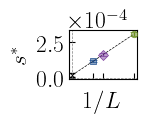

In [20]:
with open('data/SCGF_positive_data.json', 'r') as f:
    data = json.load(f)

num_sites_range = [20, 40, 60]
V = 5.875

s_range = np.array(data[f"s_range_V_{V}"])
bound = np.array(data[f"bound_V_{V}"])
activity = (bound / s_range)[1] 

s_cross = []
s_cross_err = []

for L in num_sites_range:

    large = np.array(data[f"SCGF_positive_V_{V}_L_{L}_large"])
    small = np.array(data[f"SCGF_positive_V_{V}_L_{L}_small"])

    m, b = np.polyfit(s_range[:2], large[:2], 1)

    sc = -b / (m - activity)
    sc_ref = - large[1] / np.abs(activity)

    s_cross.append(sc)
    s_cross_err.append(abs(sc - sc_ref))

x = 1 / np.array(num_sites_range)
y = np.array(s_cross)
sigma = np.array(s_cross_err)

def f(x, a, b):
    return a*x + b

popt, pcov = curve_fit(f, x, y, sigma=sigma, absolute_sigma=True)
a, b = popt
sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print("Intercept:", b, "±", sigma_b)

def cm_to_inch(cm): return cm / 2.54

fig = plt.figure(figsize=(cm_to_inch(5.5/3 + 2*0.4), cm_to_inch(4.5/4 + 2*0.4)))
ax = fig.add_axes([0.25, 0.25, 0.65, 0.65])

colors = ["#6B8E23", "#7A3E9D", "#1F4E8C"]
colors1 = [mcolors.to_rgba(c, 1.0) for c in colors]
colors03 = [mcolors.to_rgba(c, 0.5) for c in colors]
markers = ['o','D','s']

for i in range(3):
    ax.errorbar(
        x[i], y[i], yerr=sigma[i],
        linestyle='None', capsize=3,
        elinewidth=1, capthick=0.5,
        c=colors1[i], zorder=1
    )
    ax.plot(
        x[i], y[i],
        marker=markers[i], markersize=4.7,
        lw=0.0,
        c=colors03[i],
        markeredgewidth=0.5,
        markeredgecolor=colors1[i],
        zorder=3
    )

x_fit = np.linspace(0, max(x), 100)
ax.plot(x_fit, f(x_fit, a, b), '--', c='black', lw=0.5)

ax.scatter(0, b, marker='x', c='black', s=10, lw=0.5, zorder=3)
ax.errorbar(0, b, yerr=sigma_b, linestyle='None',
            capsize=2, elinewidth=0.5, c='black', lw=0.5)

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')

ax.set_xlabel(r'$1/L$', fontsize=17)
ax.set_ylabel(r'$s^*$', fontsize=17)

ax.set_xticks([1/60, 1/40, 1/20])
ax.set_xticklabels([])

ax.tick_params(axis='both', labelsize=17)

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0,0))
ax.yaxis.set_major_formatter(sf)
ax.yaxis.offsetText.set_fontsize(17)

plt.savefig('figures/svg/fig3_e_inset.svg',bbox_inches='tight',dpi=300,transparent=True)
plt.savefig('figures/pdf/fig3_e_inset.pdf',bbox_inches='tight',dpi=300,transparent=True)


plt.show()